In [56]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Simple parameters
SAMPLE_RATE = 16000
AUDIO_LENGTH = 16000
FEATURE_DIM = 16000  # Raw audio dimension

In [57]:
train_set,test_set = tf.keras.utils.audio_dataset_from_directory(
    directory=r'D:\\University\\University Work\\Semestor 5\\Ann & DL\\LAB\\ANN & DL\\Data\\Audio\\archive\\Cleaned Audio Dataset',
    batch_size=16,
    validation_split=0.2,
    seed=0,
    subset='both',
    output_sequence_length=16000
)

Found 1435 files belonging to 28 classes.
Using 1148 files for training.
Using 287 files for validation.
Using 1148 files for training.
Using 287 files for validation.


In [58]:
label_names = np.array(train_set.class_names)
label_names

array(['Ain', 'Alif', 'Ba', 'Dad', 'Dal', 'Fa', 'Ghain', 'Ha', 'Ha2',
       'Jeem', 'Kaf', 'Kha', 'Lam', 'Meem', 'Noon', 'Qaf', 'Ra', 'Sad',
       'Seen', 'Sheen', 'Ta', 'Taa', 'Thaa', 'Thal', 'Waw', 'Ya', 'Zaa',
       'Zay'], dtype='<U5')

In [59]:
def sequeeze(audio,labels):
    audio = tf.squeeze(audio,axis=-1)
    return audio,labels

In [60]:
train_set = train_set.map(sequeeze,tf.data.AUTOTUNE)
test_set = test_set.map(sequeeze,tf.data.AUTOTUNE)

In [61]:
# Normalize audio (data is already batched from audio_dataset_from_directory)
def normalize_audio(audio, labels):
    # Normalize to [-1, 1]
    audio = audio / (tf.reduce_max(tf.abs(audio)) + 1e-7)
    # Flatten from (batch, 16000) to (batch, 16000)
    audio = tf.reshape(audio, [tf.shape(audio)[0], FEATURE_DIM])
    return audio, labels

train_set = train_set.map(normalize_audio, tf.data.AUTOTUNE)
test_set = test_set.map(normalize_audio, tf.data.AUTOTUNE)

In [62]:
# Get number of classes
num_classes = len(label_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {label_names}")

Number of classes: 28
Class names: ['Ain' 'Alif' 'Ba' 'Dad' 'Dal' 'Fa' 'Ghain' 'Ha' 'Ha2' 'Jeem' 'Kaf' 'Kha'
 'Lam' 'Meem' 'Noon' 'Qaf' 'Ra' 'Sad' 'Seen' 'Sheen' 'Ta' 'Taa' 'Thaa'
 'Thal' 'Waw' 'Ya' 'Zaa' 'Zay']


In [63]:
# Build simple MLP model
def create_cnn_model(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(FEATURE_DIM,)),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create the model
model = create_cnn_model(num_classes)
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 512)            │     8,192,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,360,348 (31.89 MB)

 Trainable params: 8,360,348 (31.89 MB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Define training parameters
LEARNING_RATE = 0.001
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10
LR_REDUCE_PATIENCE = 5
MIN_LR = 0.00001

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [76]:
# Define model save paths
MODEL_CHECKPOINT_PATH = 'best_audio_model.keras'
MODEL_FINAL_PATH = r'D:\\University\\University Work\\Semestor 5\\Ann & DL\\LAB\\ANN & DL\\Model\\Mam\\audio_cnn_model.keras'
HISTORY_PATH = r'D:\\University\\University Work\\Semestor 5\\Ann & DL\\LAB\\ANN & DL\\Model\\Mam\\training_history.json'

In [77]:
# Train the model
history = model.fit(
    train_set,
    epochs=EPOCHS,
    validation_data=test_set,
    verbose=1
)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.2474 - loss: 2.9325 - val_accuracy: 0.0453 - val_loss: 3.3555
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.2474 - loss: 2.9325 - val_accuracy: 0.0453 - val_loss: 3.3555
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.4355 - loss: 2.6060 - val_accuracy: 0.0557 - val_loss: 3.3871
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.4355 - loss: 2.6060 - val_accuracy: 0.0557 - val_loss: 3.3871
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.5601 - loss: 2.2856 - val_accuracy: 0.0697 - val_loss: 3.4525
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.5601 - loss: 2.2856 - val_accuracy: 0.0697 - val_loss: 3.4525
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.6498 - loss: 1.9558 - val_accuracy: 0.0732 - val_loss: 3.5774
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.6498 - loss: 1.9558 - val_accuracy: 0.

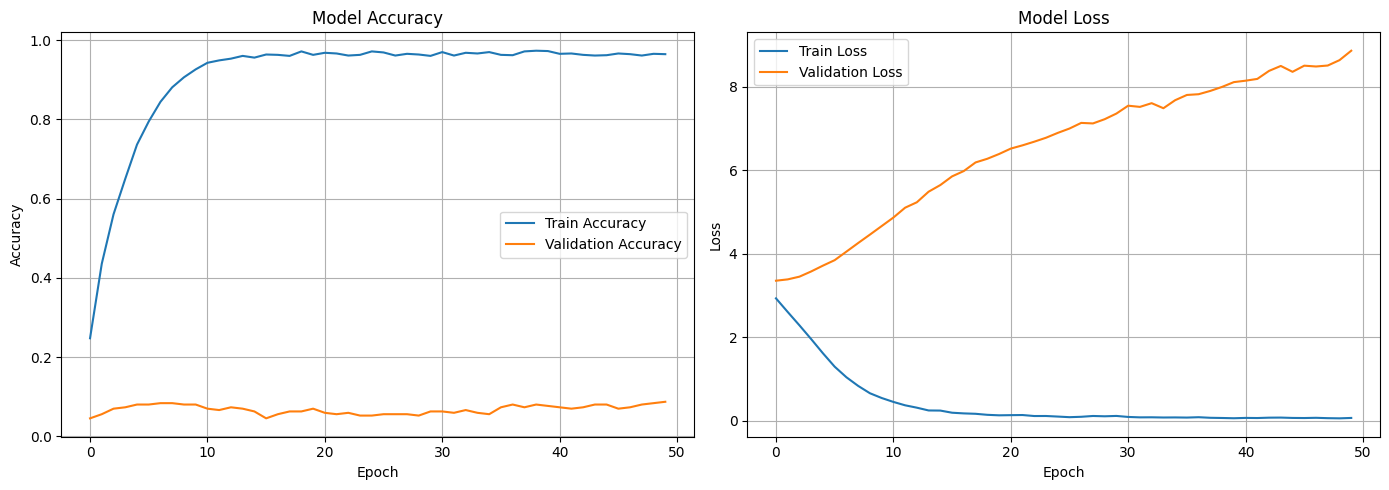

In [86]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [87]:
# Evaluate the model on test set
test_loss, test_accuracy = model.evaluate(test_set, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0871 - loss: 8.8664

Test Loss: 8.8664
Test Accuracy: 0.0871
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0871 - loss: 8.8664

Test Loss: 8.8664
Test Accuracy: 0.0871


In [88]:
# Get predictions on test set for detailed analysis
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get all predictions
predictions = []
true_labels = []

for audio, labels in test_set:
    preds = model.predict(audio, verbose=0)
    predictions.extend(np.argmax(preds, axis=1))
    true_labels.extend(labels.numpy())

predictions = np.array(predictions)
true_labels = np.array(true_labels)

# Print classification report
print("\nClassification Report:")
print(classification_report(true_labels, predictions, target_names=label_names))


Classification Report:
              precision    recall  f1-score   support

         Ain       0.20      0.10      0.13        10
        Alif       0.27      0.22      0.24        18
          Ba       0.00      0.00      0.00        15
         Dad       0.00      0.00      0.00        10
         Dal       0.00      0.00      0.00         5
          Fa       0.00      0.00      0.00        12
       Ghain       0.00      0.00      0.00         6
          Ha       0.00      0.00      0.00         8
         Ha2       0.11      0.38      0.17         8
        Jeem       0.05      0.14      0.07         7
         Kaf       0.20      0.09      0.12        11
         Kha       0.00      0.00      0.00         9
         Lam       0.00      0.00      0.00         8
        Meem       0.00      0.00      0.00         5
        Noon       0.08      0.10      0.09        10
         Qaf       0.11      0.07      0.09        14
          Ra       0.11      0.08      0.09        13
   

c:\Users\silen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\silen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\silen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

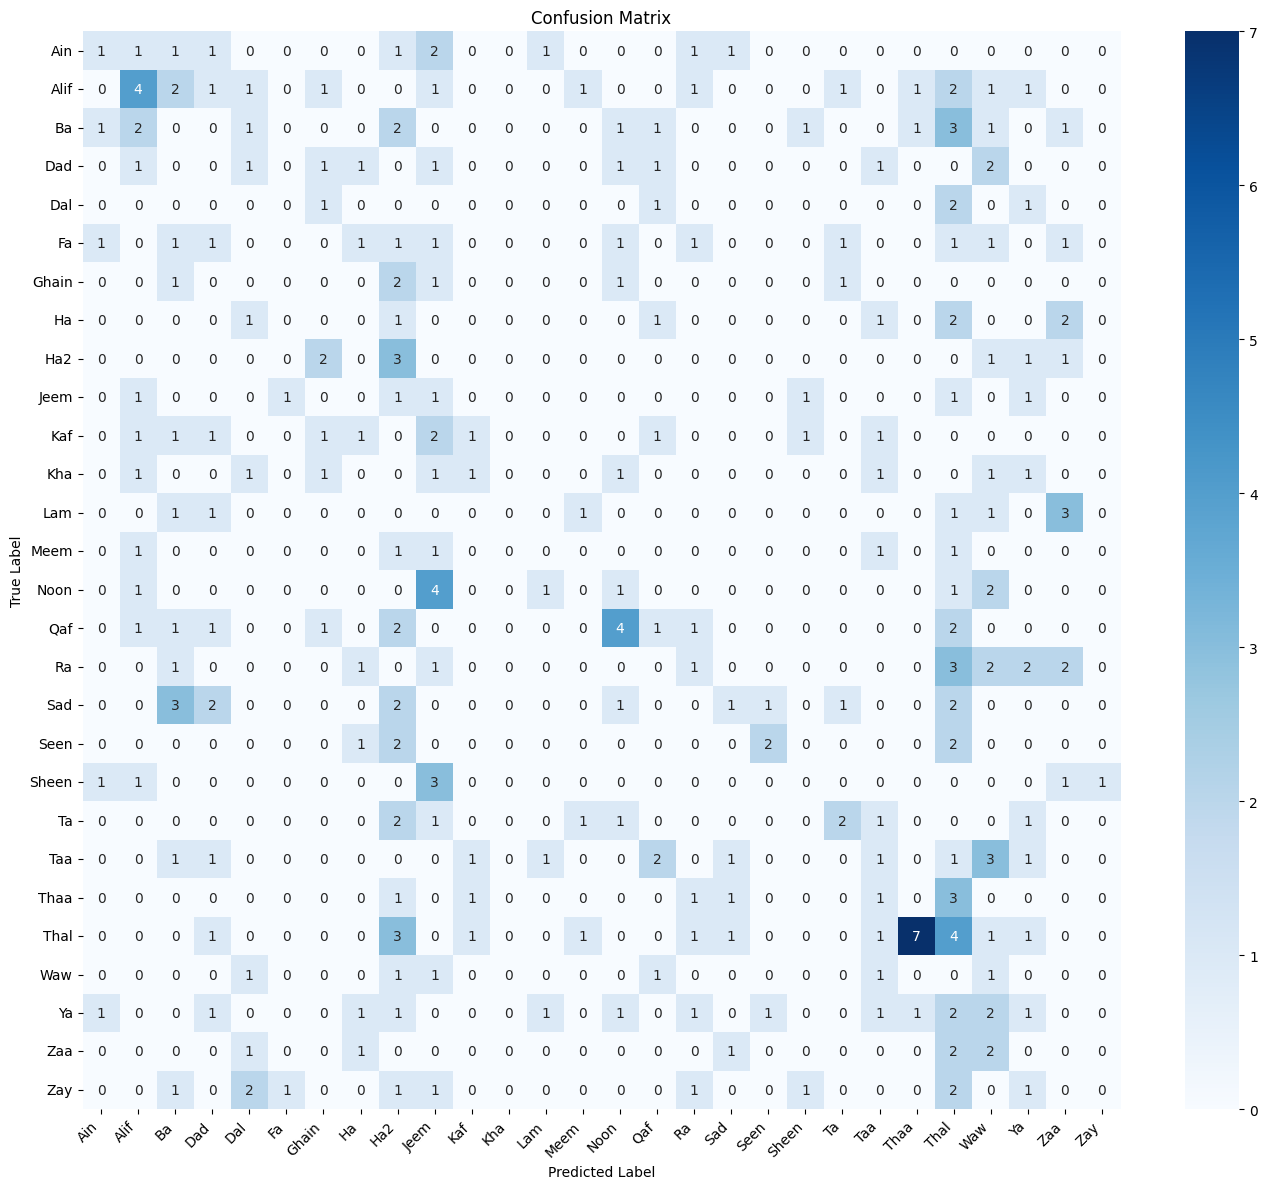

In [89]:
# Plot confusion matrix
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [90]:
# Save the final model
model.save(MODEL_FINAL_PATH)
print(f"Model saved to: {MODEL_FINAL_PATH}")

Model saved to: D:\\University\\University Work\\Semestor 5\\Ann & DL\\LAB\\ANN & DL\\Model\\Mam\\audio_cnn_model.keras


In [91]:
# Save training history to a file
import json

history_dict = {
    'accuracy': [float(x) for x in history.history['accuracy']],
    'val_accuracy': [float(x) for x in history.history['val_accuracy']],
    'loss': [float(x) for x in history.history['loss']],
    'val_loss': [float(x) for x in history.history['val_loss']]
}

with open(HISTORY_PATH, 'w') as f:
    json.dump(history_dict, f, indent=4)
print(f"Training history saved to: {HISTORY_PATH}")

Training history saved to: D:\\University\\University Work\\Semestor 5\\Ann & DL\\LAB\\ANN & DL\\Model\\Mam\\training_history.json


In [92]:
# Function to predict on new audio
def predict_audio(audio_file_path):
    """
    Predict the class of an audio file
    """
    # Load audio
    audio, sr = librosa.load(audio_file_path, sr=SAMPLE_RATE)
    
    # Pad or trim
    if len(audio) < AUDIO_LENGTH:
        audio = np.pad(audio, (0, AUDIO_LENGTH - len(audio)), 'constant')
    else:
        audio = audio[:AUDIO_LENGTH]
    
    # Normalize
    audio = audio / (np.max(np.abs(audio)) + 1e-7)
    
    # Add batch dimension
    audio_input = np.expand_dims(audio, axis=0)
    
    # Predict
    prediction = model.predict(audio_input, verbose=0)
    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0])
    
    return {
        'predicted_class': label_names[predicted_class],
        'confidence': float(confidence),
        'all_predictions': {label_names[i]: float(prediction[0][i]) for i in range(num_classes)}
    }

print("Prediction function created successfully!")

Prediction function created successfully!


In [97]:
# Test the model on sample audio files from test set
print("Testing on sample audio files from the test set:")
print("=" * 60)

# Get a few samples from test set
sample_count = 0
for audio_batch, label_batch in test_set.take(4):
    for i in range(min(1, audio_batch.shape[0])):
        audio_sample = audio_batch[i:i+1]
        true_label = label_batch[i].numpy()
        
        # Make prediction
        prediction = model.predict(audio_sample, verbose=0)
        predicted_class = np.argmax(prediction[0])
        confidence = np.max(prediction[0])
        
        print(f"\nSample {sample_count + 1}:")
        print(f"True Label: {label_names[true_label]}")
        print(f"Predicted Label: {label_names[predicted_class]}")
        print(f"Confidence: {confidence:.4f}")
        print(f"Match: {'✓' if predicted_class == true_label else '✗'}")
        sample_count += 1

Testing on sample audio files from the test set:

Sample 1:
True Label: Qaf
Predicted Label: Ghain
Confidence: 0.3911
Match: ✗

Sample 2:
True Label: Alif
Predicted Label: Meem
Confidence: 0.9069
Match: ✗

Sample 1:
True Label: Qaf
Predicted Label: Ghain
Confidence: 0.3911
Match: ✗

Sample 2:
True Label: Alif
Predicted Label: Meem
Confidence: 0.9069
Match: ✗

Sample 3:
True Label: Jeem
Predicted Label: Fa
Confidence: 0.9543
Match: ✗

Sample 4:
True Label: Dad
Predicted Label: Alif
Confidence: 0.9999
Match: ✗

Sample 3:
True Label: Jeem
Predicted Label: Fa
Confidence: 0.9543
Match: ✗

Sample 4:
True Label: Dad
Predicted Label: Alif
Confidence: 0.9999
Match: ✗
